In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

# 학습셋(6만개) -> 검증셋(1만개)+훈련셋(5만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 학습셋(5만개: fit용), 검증셋(1만:fit용), 테스트셋(1만, 평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

# 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠서)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
print(train_X.shape, val_X.shape, test_X.shape)

# 훈련셋5만개, -> 40000개, 테스트셋 1만개 -> 9000개 추출 (목적: 학습시간 고려하되 모든 데이터 이용)
train_idx = np.random.choice(50000, 50000)
val_idx = np.random.choice(10000, 10000)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]
print(train_X.shape, y_train.shape, val_X.shape, y_val.shape, test_X.shape, y_test.shape)

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1568, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=784, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=196, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=49, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 타겟(종속)변수의 원핫코딩
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val, 10)
test_Y = to_categorical(y_test, 10)
print(y_train[:2])
print(train_Y[:2])

train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)
(50000, 784) (10000, 784) (10000, 784)
(50000, 784) (50000,) (10000, 784) (10000,) (10000, 784) (10000,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1568)           │     1,230,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │     1,230,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 196)            │       153,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 49)             │         9,653 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,989 (10.01 MB)

 Trainable params: 2,624,989 (10.01 MB)

 Non-trainable params: 0 (0.00 B)

[6 5]
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [5]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy', # sparce_categorical_crossentropy
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

hist = model.fit(train_X, train_Y, # 훈련데이터
                epochs=30, # 학습횟수
                batch_size=10000, # 한번에 읽어들이는 데이터 양
                validation_data=(val_X, val_Y), # 검증 데이터
#                 validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1 # 학습 로그 출력 여부 (0: 출력x, 1:출력o(default), 2:출력자세히o)
                )

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - accuracy: 0.1810 - loss: 2.5871 - precision_1: 0.3438 - recall_1: 0.0427 - val_accuracy: 0.1839 - val_loss: 2.2589 - val_precision_1: 0.7701 - val_recall_1: 0.0995
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2133 - loss: 2.1929 - precision_1: 0.7984 - recall_1: 0.0997 - val_accuracy: 0.2753 - val_loss: 1.7541 - val_precision_1: 0.9477 - val_recall_1: 0.0925
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3686 - loss: 1.7131 - precision_1: 0.9337 - recall_1: 0.1025 - val_accuracy: 0.5541 - val_loss: 1.4216 - val_precision_1: 0.9142 - val_recall_1: 0.1033
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5162 - loss: 1.4251 - precision_1: 0.8455 - recall_1: 0.1921 - val_accuracy: 0.6291 - val_loss: 1.1265 - val_precision_1: 0.8835 - val_recall_1: 0.3389
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6181 - loss: 1.1531 - precision_1: 0.8639 - recall_1: 0.3393 - val_accuracy:

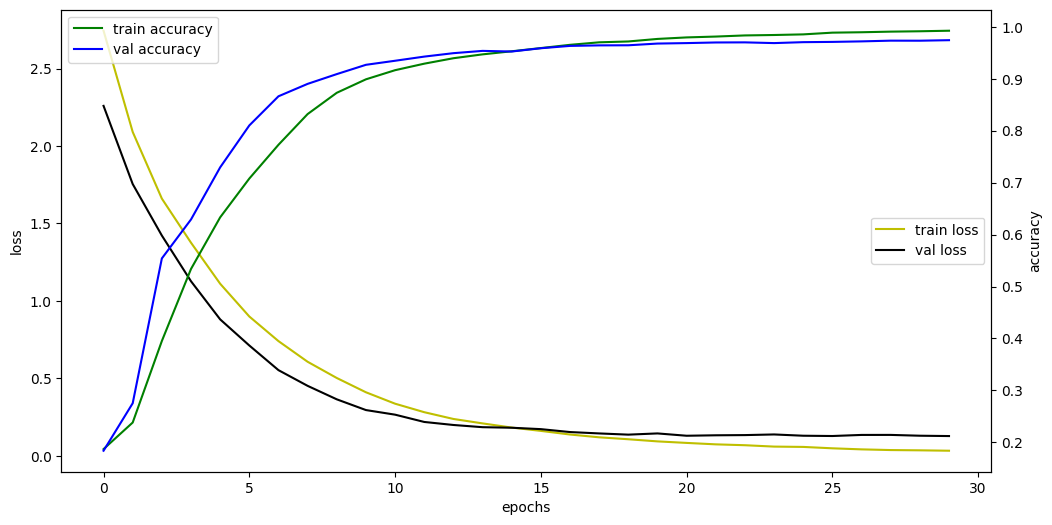

In [6]:
hist.history.keys()
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
# acc_ax.plot(hist.history['recall_3'], 'g', label='train recall')
# acc_ax.plot(hist.history['precision_3'], 'g', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
# acc_ax.plot(hist.history['val_recall_3'], 'b', label='val recall')
# acc_ax.plot(hist.history['val_precision_3'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [7]:
# 모델 평가하기
loss_and_mertics = model.evaluate(test_X, test_Y, batch_size=1000, verbose=1)

# 교차표
y_hat = model.predict(test_X).argmax(axis=1)
print(y_hat)
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9711 - loss: 0.1428 - precision_1: 0.9736 - recall_1: 0.9703
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]


예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,969,0,0,2,1,1,5,1,1,0
1,0,1125,4,0,0,0,2,0,4,0
2,4,2,1005,2,3,1,1,7,6,1
3,0,0,5,983,0,6,0,6,7,3
4,0,0,5,0,963,2,3,2,0,7
5,5,0,1,10,1,859,4,1,9,2
6,4,3,1,0,4,5,938,0,3,0
7,0,3,10,3,0,1,0,1002,1,8
8,2,0,4,6,9,5,0,6,938,4


In [8]:
model.save('/content/drive/MyDrive/MBC아카데미/model/mnist.h5')

In [10]:
pd.read_csv('/content/drive/MyDrive/MBC아카데미/model/winequality-red.csv', sep=';')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
